In [6]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 50.0 MB/s eta 0:00:00


In [7]:
from rdkit import Chem
from rdkit.Chem import Descriptors

print("RDKit is ready to scout!")

RDKit is ready to scout!


In [8]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. We define the molecule using its SMILES code
aspirin_smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"
mol = Chem.MolFromSmiles(aspirin_smiles)

# 2. We ask RDKit to calculate the weight
weight = Descriptors.MolWt(mol)

# 3. We print the result
print(f"The weight of Aspirin is: {weight:.2f}")

The weight of Aspirin is: 180.16


In [9]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. We create a small "library" of 3 molecules
data = {
    'Name': ['Aspirin', 'Caffeine', 'Paracetamol'],
    'SMILES': ['CC(=O)OC1=CC=CC=C1C(=O)O', 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C', 'CC(=O)NC1=CC=C(O)C=C1']
}

# 2. We turn it into a Pandas DataFrame (a professional table)
df = pd.DataFrame(data)

# 3. Let's see what our "Library" looks like
print("Here is our chemical library:")
print(df)

Here is our chemical library:
          Name                        SMILES
0      Aspirin      CC(=O)OC1=CC=CC=C1C(=O)O
1     Caffeine  CN1C=NC2=C1C(=O)N(C(=O)N2C)C
2  Paracetamol         CC(=O)NC1=CC=C(O)C=C1


In [10]:
# 1. We create a function to get the weight from a SMILES string
def get_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:  # Only calculate if the molecule is valid
        return Descriptors.MolWt(mol)
    else:
        return None # If it's a bad structure, just leave it empty

# 2. We apply this function to the entire 'SMILES' column at once
df['Molecular_Weight'] = df['SMILES'].apply(get_weight)

# 3. Look at your updated warehouse
print(df)

          Name                        SMILES  Molecular_Weight
0      Aspirin      CC(=O)OC1=CC=CC=C1C(=O)O           180.159
1     Caffeine  CN1C=NC2=C1C(=O)N(C(=O)N2C)C           194.194
2  Paracetamol         CC(=O)NC1=CC=C(O)C=C1           151.165


In [11]:
# A list with two good molecules and one "bad" string (garbage)
bad_data = {
    'Name': ['Aspirin', 'Garbage', 'Caffeine'],
    'SMILES': ['CC(=O)OC1=CC=CC=C1C(=O)O', 'THIS_IS_NOT_A_MOLECULE', 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C']
}

df_test = pd.DataFrame(bad_data)

# Run our same calculation
df_test['Molecular_Weight'] = df_test['SMILES'].apply(get_weight)

print(df_test)

       Name                        SMILES  Molecular_Weight
0   Aspirin      CC(=O)OC1=CC=CC=C1C(=O)O           180.159
1   Garbage        THIS_IS_NOT_A_MOLECULE               NaN
2  Caffeine  CN1C=NC2=C1C(=O)N(C(=O)N2C)C           194.194


[04:35:31] SMILES Parse Error: syntax error while parsing: THIS_IS_NOT_A_MOLECULE
[04:35:31] SMILES Parse Error: check for mistakes around position 1:
[04:35:31] THIS_IS_NOT_A_MOLECULE
[04:35:31] ^
[04:35:31] SMILES Parse Error: Failed parsing SMILES 'THIS_IS_NOT_A_MOLECULE' for input: 'THIS_IS_NOT_A_MOLECULE'


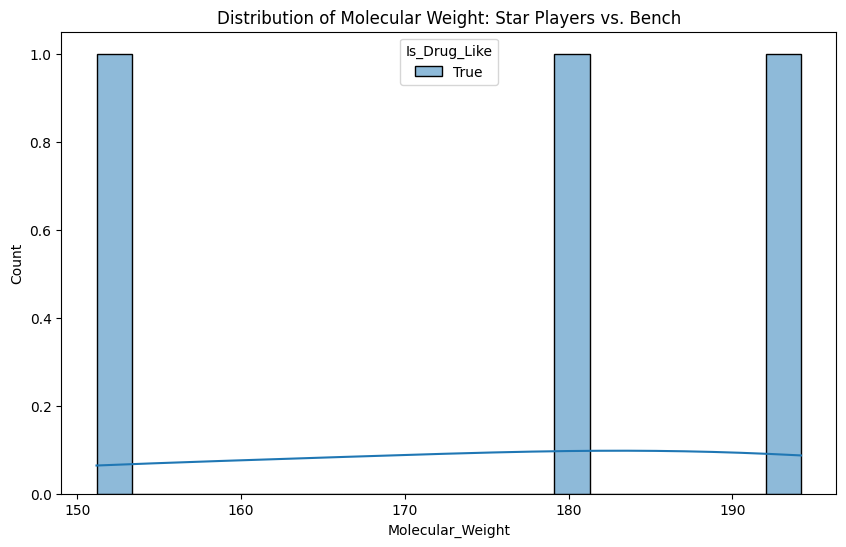

In [12]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Redefine the function so Python remembers it
def is_drug_like(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return False
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    return mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10

# 2. Re-calculate the column
df['Is_Drug_Like'] = df['SMILES'].apply(is_drug_like)

# 3. Now, generate the plot!
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Molecular_Weight', hue='Is_Drug_Like', kde=True, bins=20)
plt.title('Distribution of Molecular Weight: Star Players vs. Bench')
plt.show()

In [13]:
!pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00


In [14]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

# 1. Search for the target
target = new_client.target
target_query = target.search('acetylcholinesterase')

# 2. Convert to DataFrame the standard way
targets = pd.DataFrame.from_records(target_query)

# 3. See the results
print(targets.head())

  cross_references                 organism             pref_name  score  \
0               []  Drosophila melanogaster  Acetylcholinesterase   18.0   
1               []  Drosophila melanogaster  Acetylcholinesterase   18.0   
2               []             Homo sapiens  Acetylcholinesterase   16.0   
3               []      Torpedo californica  Acetylcholinesterase   16.0   
4               []             Mus musculus  Acetylcholinesterase   16.0   

   species_group_flag target_chembl_id  \
0               False    CHEMBL2242744   
1               False    CHEMBL2242744   
2               False        CHEMBL220   
3               False       CHEMBL4780   
4               False       CHEMBL3198   

                                   target_components     target_type  tax_id  
0  [{'accession': 'P07140', 'component_descriptio...  SINGLE PROTEIN    7227  
1  [{'accession': 'P07140', 'component_descriptio...  SINGLE PROTEIN    7227  
2  [{'accession': 'P22303', 'component_descriptio... 

In [15]:
# This keeps only the specific proteins and ignores the broad groups
targets = targets[targets['species_group_flag'] == False]

In [16]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

# We only ask for the specific columns we need to save bandwidth
activity = new_client.activity
res = activity.filter(target_chembl_id='CHEMBL220').filter(standard_type='IC50').only('molecule_chembl_id', 'canonical_smiles', 'standard_value')

# We take a sample (e.g., 1000 records) to ensure it executes quickly
df_bio = pd.DataFrame.from_records(res[:1000])

# Check the first few rows and the shape of our data
print(df_bio.head())
print("Data shape:", df_bio.shape)

                                    canonical_smiles molecule_chembl_id  \
0              CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1       CHEMBL133897   
1              CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1       CHEMBL133897   
2         O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1       CHEMBL336398   
3  CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1       CHEMBL131588   
4      O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F       CHEMBL130628   

  standard_value value  
0          750.0  0.75  
1          750.0  0.75  
2          100.0   0.1  
3        50000.0  50.0  
4          300.0   0.3  
Data shape: (1001, 4)


In [17]:
# A & B: Cleaning the data in one flow
# 1. Drop rows where standard_value is missing (NaN)
df_clean = df_bio.dropna(subset=['standard_value'])

# 2. Remove duplicates keeping the first occurrence (or you could take the mean)
df_clean = df_clean.drop_duplicates(subset=['molecule_chembl_id'])

# Check the difference
print(f"Original shape: {df_bio.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (1001, 4)
Cleaned shape: (743, 4)


In [18]:
import numpy as np

# Define a function to convert nM to pIC50
def pIC50(input_df):
    pIC50_list = []

    # We must ensure standard_value is numeric
    for i in input_df['standard_value']:
        molar = float(i) * (10**-9) # Convert nM to M
        pIC50_val = -np.log10(molar)
        pIC50_list.append(pIC50_val)

    input_df['pIC50'] = pIC50_list
    return input_df

# Apply the function
df_final = pIC50(df_clean.copy())

# Check the results
print(df_final[['standard_value', 'pIC50']].head())

  standard_value     pIC50
0          750.0  6.124939
2          100.0  7.000000
3        50000.0  4.301030
4          300.0  6.522879
5          800.0  6.096910


In [19]:
# Create a function to label the bioactivity
def label_bioactivity(val):
    if val >= 7.0:
        return "Active"
    elif val <= 5.0:
        return "Inactive"
    else:
        return "Intermediate"

# Apply the labeling
df_final['bioactivity_class'] = df_final['pIC50'].apply(label_bioactivity)

# Take a final look
print(df_final[['molecule_chembl_id', 'pIC50', 'bioactivity_class']].head(20))

   molecule_chembl_id     pIC50 bioactivity_class
0        CHEMBL133897  6.124939      Intermediate
2        CHEMBL336398  7.000000            Active
3        CHEMBL131588  4.301030          Inactive
4        CHEMBL130628  6.522879      Intermediate
5        CHEMBL130478  6.096910      Intermediate
6        CHEMBL130112  5.619789      Intermediate
7        CHEMBL130098  7.000000            Active
8        CHEMBL337486  4.301030          Inactive
9        CHEMBL336538  6.096910      Intermediate
10       CHEMBL131051  4.301030          Inactive
11       CHEMBL341437  4.301030          Inactive
12       CHEMBL335033  7.301030            Active
13       CHEMBL122983  4.000000          Inactive
14       CHEMBL338720  6.251812      Intermediate
15       CHEMBL339995  8.000000            Active
16       CHEMBL335158  8.000000            Active
17       CHEMBL131536  5.853872      Intermediate
18       CHEMBL106126  4.769551          Inactive
19       CHEMBL334971  5.958607      Intermediate


In [20]:
# Example logic for labeling safety
def label_safety(pIC50, predicted_toxicity_score):
    # If it's potent (pIC50 > 7) AND toxicity is low
    if pIC50 > 7.0 and predicted_toxicity_score < 0.2:
        return "Ideal Candidate"
    elif pIC50 > 7.0 and predicted_toxicity_score >= 0.2:
        return "Potent but Toxic"
    else:
        return "Not Ideal"

In [22]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

# 1. Re-define the calculation
def get_mw(smiles): return Descriptors.MolWt(Chem.MolFromSmiles(smiles))
def get_logp(smiles): return Descriptors.MolLogP(Chem.MolFromSmiles(smiles))
def get_hdonors(smiles): return Lipinski.NumHDonors(Chem.MolFromSmiles(smiles))
def get_hacceptors(smiles): return Lipinski.NumHAcceptors(Chem.MolFromSmiles(smiles))

# 2. Add them as new columns directly
df_final['MW'] = df_final['canonical_smiles'].apply(get_mw)
df_final['LogP'] = df_final['canonical_smiles'].apply(get_logp)
df_final['NumHDonors'] = df_final['canonical_smiles'].apply(get_hdonors)
df_final['NumHAcceptors'] = df_final['canonical_smiles'].apply(get_hacceptors)

# 3. Now run the filter again
def lipinski_filter(row):
    violations = 0
    if row['MW'] > 500: violations += 1
    if row['LogP'] > 5: violations += 1
    if row['NumHDonors'] > 5: violations += 1
    if row['NumHAcceptors'] > 10: violations += 1
    return "Pass" if violations <= 1 else "Fail"

df_final['Lipinski_Result'] = df_final.apply(lipinski_filter, axis=1)

# 4. Check results
print(df_final['Lipinski_Result'].value_counts())

Lipinski_Result
Pass    692
Fail     51
Name: count, dtype: int64


In [23]:
# Create a column to count violations (0, 1, 2, 3, or 4)
def count_violations(row):
    violations = 0
    if row['MW'] > 500: violations += 1
    if row['LogP'] > 5: violations += 1
    if row['NumHDonors'] > 5: violations += 1
    if row['NumHAcceptors'] > 10: violations += 1
    return violations

# Add the count to your dataframe
df_final['Violation_Count'] = df_final.apply(count_violations, axis=1)

# Filter for the "Pass" group and count 0 vs 1 violations
pass_group = df_final[df_final['Lipinski_Result'] == 'Pass']
violation_distribution = pass_group['Violation_Count'].value_counts().sort_index()

print("Breakdown of the 692 molecules that Passed:")
print(violation_distribution)

Breakdown of the 692 molecules that Passed:
Violation_Count
0    605
1     87
Name: count, dtype: int64


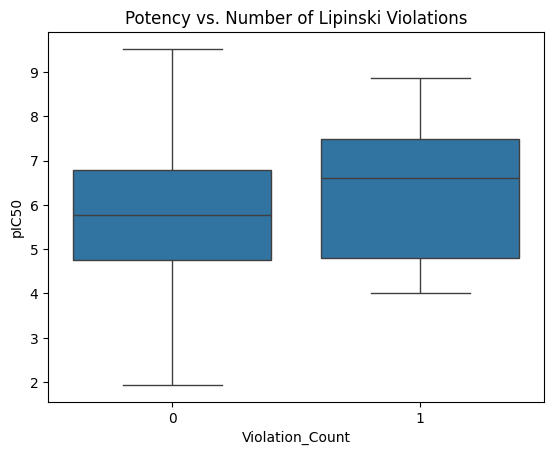

Violation_Count
0    5.724823
1    6.348243
Name: pIC50, dtype: float64


In [24]:
# Comparison of pIC50 for 0 vs 1 violation
sns.boxplot(x='Violation_Count', y='pIC50', data=pass_group)
plt.title('Potency vs. Number of Lipinski Violations')
plt.show()

# Print the average potency for both
print(pass_group.groupby('Violation_Count')['pIC50'].mean())